In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path to your dataset
data_path = "C:/plant-disease-ai/data/plantvillage dataset/color"

# Count how many disease categories we have
categories = os.listdir(data_path)
print(f"Total disease categories: {len(categories)}")
print("\nFirst 5 categories:")
for cat in categories[:5]:
    print(" →", cat)

Total disease categories: 38

First 5 categories:
 → Apple___Apple_scab
 → Apple___Black_rot
 → Apple___Cedar_apple_rust
 → Apple___healthy
 → Blueberry___healthy


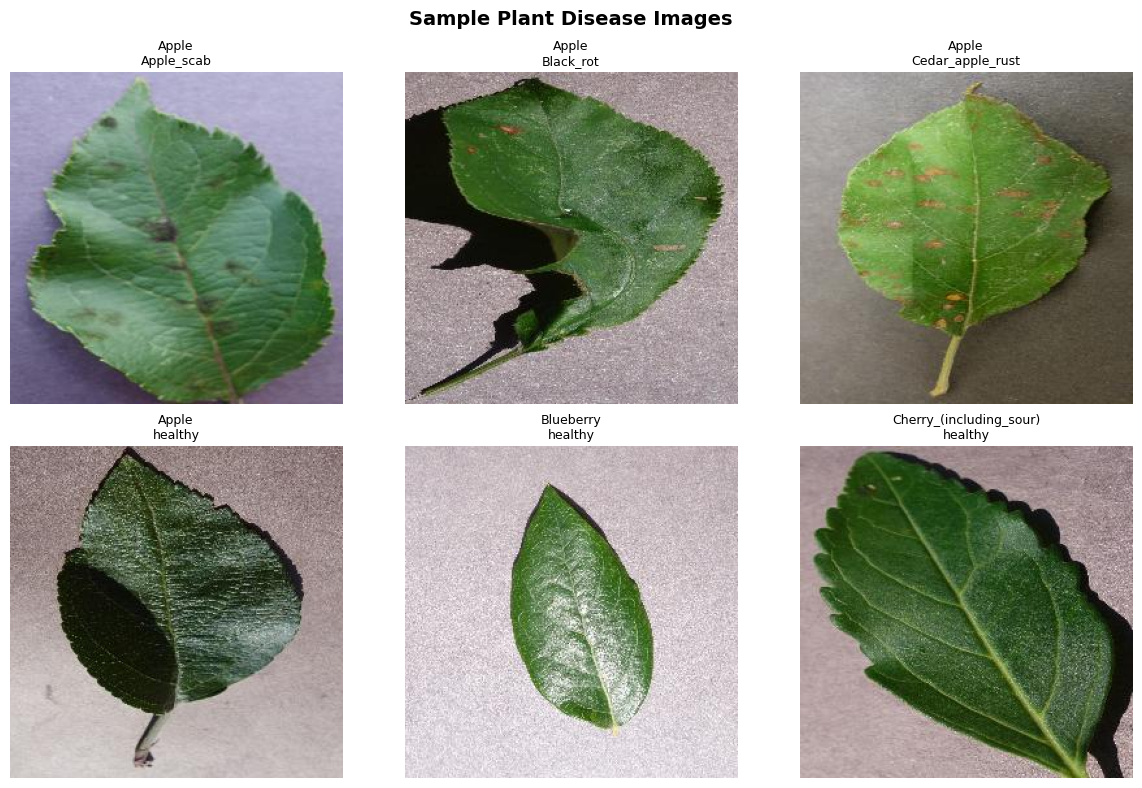

In [2]:
# Display one sample image from each of the first 6 disease categories
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, category in enumerate(categories[:6]):
    category_path = os.path.join(data_path, category)
    img_file = os.listdir(category_path)[0]  # First image in the folder
    img = Image.open(os.path.join(category_path, img_file))
    
    axes[i].imshow(img)
    axes[i].set_title(category.replace("___", "\n"), fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Plant Disease Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
# Count total images and show distribution
total_images = 0
print(f"{'Category':<45} {'Images':>6}")
print("-" * 53)

for category in sorted(categories):
    category_path = os.path.join(data_path, category)
    count = len(os.listdir(category_path))
    total_images += count
    print(f"{category:<45} {count:>6}")

print("-" * 53)
print(f"{'TOTAL':<45} {total_images:>6}")

Category                                      Images
-----------------------------------------------------
Apple___Apple_scab                               630
Apple___Black_rot                                621
Apple___Cedar_apple_rust                         275
Apple___healthy                                 1645
Blueberry___healthy                             1502
Cherry_(including_sour)___Powdery_mildew        1052
Cherry_(including_sour)___healthy                854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    513
Corn_(maize)___Common_rust_                     1192
Corn_(maize)___Northern_Leaf_Blight              985
Corn_(maize)___healthy                          1162
Grape___Black_rot                               1180
Grape___Esca_(Black_Measles)                    1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)      1076
Grape___healthy                                  423
Orange___Haunglongbing_(Citrus_greening)        5507
Peach___Bacterial_spot                  

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.21.0
All libraries loaded successfully!


In [2]:
# Settings
data_path = "C:/plant-disease-ai/data/plantvillage dataset/color"
IMG_SIZE = 224        # MobileNetV2 expects 224x224 images
BATCH_SIZE = 32       # Process 32 images at a time
SPLIT = 0.2           # 20% for testing, 80% for training

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train/Test split: 80% / 20%")

Image size: 224x224
Batch size: 32
Train/Test split: 80% / 20%


In [3]:
# Training data generator - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,        # Randomly rotate images slightly
    width_shift_range=0.2,    # Randomly shift images left/right
    height_shift_range=0.2,   # Randomly shift images up/down
    horizontal_flip=True,     # Randomly flip images
    validation_split=SPLIT    # Reserve 20% for testing
)

# Load training images
train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation images
val_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [4]:
# Check our data is ready
print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Number of classes: {train_data.num_classes}")
print(f"\nClass names sample:")
class_names = list(train_data.class_indices.keys())
for name in class_names[:5]:
    print(f"  → {name}")

Training batches: 1358
Validation batches: 340
Number of classes: 38

Class names sample:
  → Apple___Apple_scab
  → Apple___Black_rot
  → Apple___Cedar_apple_rust
  → Apple___healthy
  → Blueberry___healthy


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import os

print("Libraries loaded!")
print("TensorFlow version:", tf.__version__)

Libraries loaded!
TensorFlow version: 2.21.0


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_path = "C:/plant-disease-ai/data/plantvillage dataset/color"
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data ready!")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Data ready!


In [7]:
# Step 1 — Load MobileNetV2 (pretrained on 1 million images!)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # Remove its original output layer
    weights='imagenet'          # Use pretrained weights
)

# Step 2 — Freeze the base (don't retrain what's already learned)
base_model.trainable = False

# Step 3 — Add YOUR custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)     # Flatten the features
x = Dropout(0.3)(x)                  # Prevent overfitting
output = Dense(38, activation='softmax')(x)  # 38 disease classes

# Step 4 — Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Step 5 — Compile it
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built successfully!")
print(f"Total layers: {len(model.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model built successfully!
Total layers: 157


In [8]:
# Show last 10 layers only (full summary is very long!)
print("Last 10 layers of your model:\n")
for layer in model.layers[-10:]:
    print(f"  {layer.name:<40} → {layer.output_shape}")

Last 10 layers of your model:



AttributeError: 'BatchNormalization' object has no attribute 'output_shape'

In [9]:
# Train the model!
history = model.fit(
    train_data,    
    epochs=10,                    # Go through all data 10 times
    validation_data=val_data,
    verbose=1                     # Show progress for each epoch
)

print("\nTraining complete! 🎉")

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 621s 456ms/step - accuracy: 0.8159 - loss: 0.6389 - val_accuracy: 0.9055 - val_loss: 0.2970
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 703s 518ms/step - accuracy: 0.8967 - loss: 0.3261 - val_accuracy: 0.9181 - val_loss: 0.2534
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 720s 530ms/step - accuracy: 0.9080 - loss: 0.2827 - val_accuracy: 0.9273 - val_loss: 0.2228
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 703s 518ms/step - accuracy: 0.9109 - loss: 0.2724 - val_accuracy: 0.9343 - val_loss: 0.2066
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 583s 429ms/step - accuracy: 0.9153 - loss: 0.2568 - val_accuracy: 0.9348 - val_loss: 0.2044
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 558s 411ms/step - accuracy: 0.9136 - loss: 0.2570 - val_accuracy: 0.9319 - val_loss: 0.2058
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 625s 460ms/step - accuracy: 0.9185 - loss: 0.2460 - val_accuracy: 0.9371 - val_loss: 0.1907
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 659s 485ms/step - ac

In [1]:
# Save your trained model
model.save("C:/plant-disease-ai/models/plant_disease_model.h5")
print("Model saved successfully!")

# Also save the class names for later use
import json
class_names = list(train_data.class_indices.keys())
with open("C:/plant-disease-ai/models/class_names.json", "w") as f:
    json.dump(class_names, f)
print(f"Saved {len(class_names)} class names!")

NameError: name 'model' is not defined